# Part I: Conformal Regression

We consider a simple regression problem on heteroskedastic data. We want to evaluate the uncertainty associated with the prediction using various conformal prediction methods. The main objective of this first part is to get a better grasp of how Conformal Prediction works, and to *visualize* the effect of the different algorithms on the coverage rate and the size of the prediction intervals. We will code most of the algorithms from scratch, and compare our results with those obtained with help of the PUNCC library for verification purposes.

**Links**
- [PUNCC Github](https://github.com/deel-ai/puncc)
- [PUNCC Documentation](https://deel-ai.github.io/puncc/index.html)

**Warning!** We will be working on tensorflow and not on pytorch. Make sure to use the jupyter kernel associated with the tensorflow environment !

## 0. Setup

**Exercise.** Install the puncc library using pip

In [156]:
# TODO: install the PUNCC library

We import some of the libraries that we will be using throughout.

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

## 1. Dataset

We consider a synthetic 1D heteroskedastic dataset, where the variance of the noise increases with the value of the input feature.
We generate $N$ samples as follows:

- Inputs $X$ are uniformly distributed on $[0, 20]$
- Outputs are given by $Y = (1+\epsilon)\cdot X, $

Such that $\epsilon \sim {\cal N}(\mu=0,\sigma=1)$ is standard gaussian noise.

**Exercise.**
1. Complete the function `heteroskedastic_data` that takes the number of samples `n_samples` to be generated as an arguments, and outputs numpy arrays `X` and `y` of size `n_samples` according to the procedure described above.
2. Use the `heteroskedastic_data` function to generate 4000 samples.

In [158]:
np.random.seed(16)

In [159]:
# Generate synthetic 1D heteroskedastic data

def heteroskedastic_data(n_samples, begin=0, end=20):
    X = np.linspace(begin, end, n_samples)
    noise = 0.5 + 0.5 * X  # Heteroskedastic noise
    y = np.sin(X) + np.random.normal(0, noise)
    return X.reshape(-1, 1), y


# Generate 4000 samples
X, y = heteroskedastic_data(4000)

In [160]:
# %load solutions/data/heteroskedastic_data.py

**Exercise.** Complete the function `plot_data below`, and use it to plot the synthetic data.

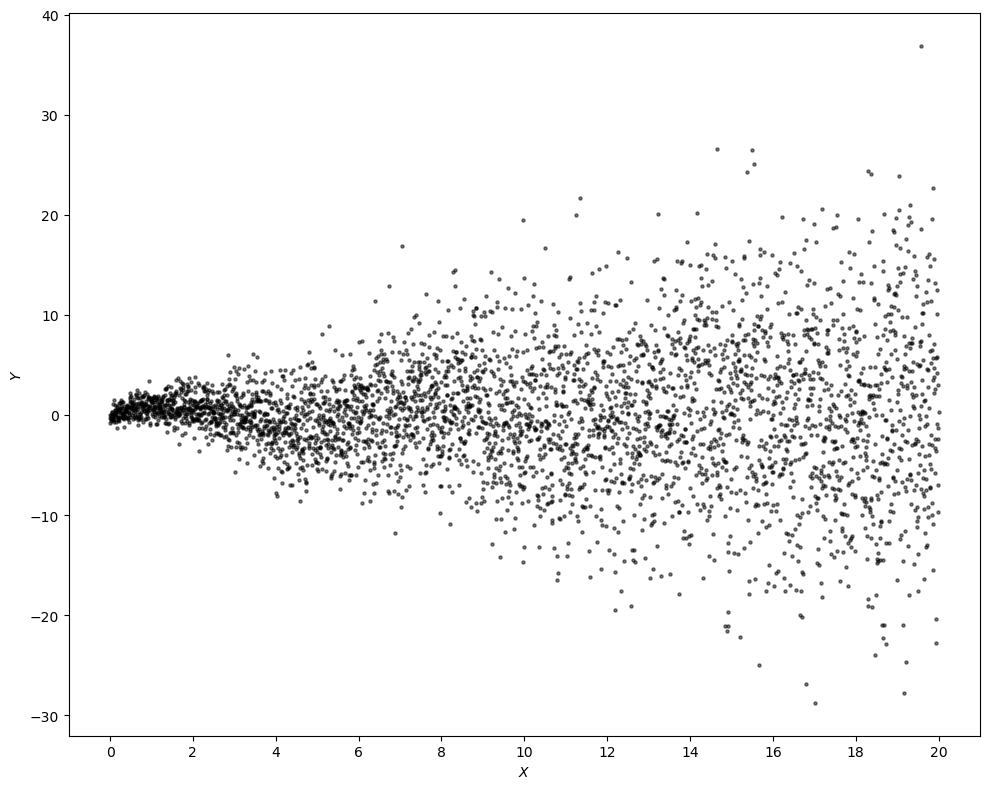

In [161]:
def plot_data(X, y):
    plt.figure(figsize=(10, 8))
    plt.scatter(X, y, s=5, color="black", alpha=0.5)
    plt.xlabel(r"$X$")
    plt.ylabel(r"$Y$")
    plt.xticks(np.arange(22, step=2))
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# TODO: plot the data
plot_data(X, y)

In [162]:
# %load solutions/data/plot_data.py

**Exercise.** Split the data into a training set and a test set by using the `train_test_split` function of the `scikit-learn` library. Split the data randomly and leaving out 25% of the data for the test set.

In [163]:
from sklearn.model_selection import train_test_split

# Split the data into training, calibration, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [164]:
# %load solutions/data/split_test.py

## 2. Split Conformal Regression

In order to perform the *split conformal regression* algorithm, we need to split our training data into a *proper training set* (which we will store in the variables `X_fit` and `y_fit`) and a *calibration set*.

**Exercise.** Further split the training data randomly by leaving out 50% of the training data for the calibration set.

In [165]:
X_fit, X_calib, y_fit, y_calib = train_test_split(X_train, y_train, test_size=0.5, random_state=42)

In [166]:
# %load solutions/split/split_calib.py

**Exercise.** Train a prediction model using the `LinearRegression` class in the `scikit-learn` library.

In [167]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_fit, y_fit)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
# %load solutions/split/train_regressor.py

**Exercise.** Complete the `plot_model` function below in order to plot synthetic data along with the model predictions. Use the function `plot_model` to plot the test data along with the model predictions.

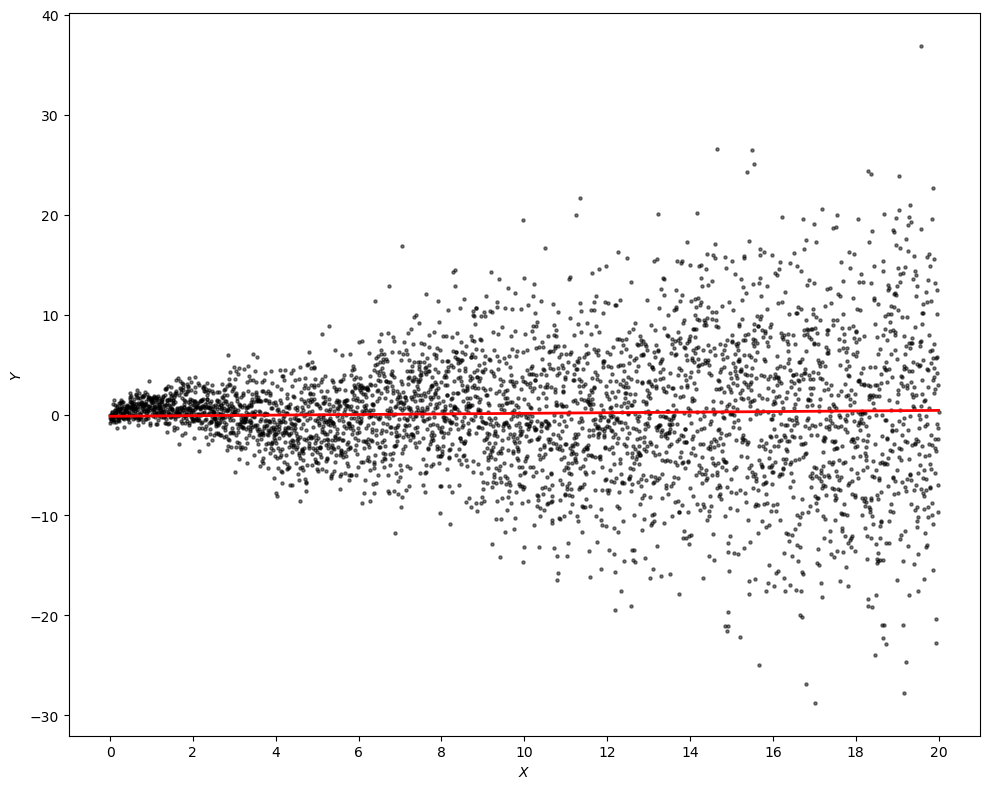

In [169]:
def plot_model(model, X, y):
    plt.figure(figsize=(10, 8))
    # TODO: plot the data
    plt.scatter(X, y, s=5, color="black", alpha=0.5)
    # TODO: plot the model predictions
    X_plot = np.linspace(0, 20, 400).reshape(-1, 1)
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, color="red", linewidth=2)
    plt.xlabel(r"$X$")
    plt.ylabel(r"$Y$")
    plt.xticks(np.arange(22, step=2))
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# TODO: visualize the data and model in the same plot
plot_model(reg, X, y)

In [170]:
# %load solutions/split/plot_regressor.py

Now that we have a trained model, we wish to *conformalize* it. The simplest algorithm to conformalize a model is the *split conformal* algorithm.

In this section, we are using the split conformal algorithm for the regression task, but as we have seen in the lectures, there are many other conformalization algorithms that rely on splitting the data into a train/fit and a calibration set. Therefore, we will coda a generic class called `SplitConformal` that we will be able to use later for other conformal prediction algorithms of the *split* type.

In order to define our general `SplitConformal` class, we will rely on the following information:
the algorithms using the `SplitConformal` class are different between each other only in two ways:
- the way the *nonconformity scores* are computed,
- the way the *prediction sets* are constructed.

Therefore, we will build the `SplitConformal` class so that it can work with any choice of *nonconformity score function* and *prediction set contruction function*.


**Exercise.** Code the `SplitConformal` class by implementing the following:
1. Attributes:
  - `score_fn`: the nonconformity score function to be used (a function that computes scores between ground truth values and model predictions).
  - `predset_fn`: the prediction set construction function to be used (a function that builds prediction sets from model predictions and quantile values).
  - `scores`: attribute to store the array of calibration nonconformity scores.
  - `quantile`: attribute to store the value of the quantile of order $1-\alpha$ (plus correction).

2. Methods:
  - `__init__`: takes as input the choice of nonconformity score function and prediction set construction function.
  - `compute_scores`: takes as input a numpy array containing ground truth $y$-values and predicted $y$-values, computes the nonconformity scores, and stores them into the attribute `scores`.
  - `compute_quantile`: takes as input the nominal error rate $\alpha$ and computes the quantile of level $1-\alpha$ (taking into account the usual finite-sample correction characteristic of conformal prediction algorithms) on the array of scores saved in the `scores` attribute. **Warning!** You may use the `quantile` function in the `numpy` library, however, make sure you choose the *right* method to compute the quantile values, otherwise the probabilistic guarantee of conformal prediction will no longer be true. (**This is an important point, try and understand the different methods and choose the correct one yourself before checking the solutions!!!**)
  - `predict`: takes as input an array of model predictions and outputs prediction sets (in whatever format the `predset_fn` outputs prediction sets).

In [222]:
from typing import Optional, Callable

class SplitConformal():
    def __init__(self, model, score_fn, predset_fn, alpha=0.1):
        self.model = model
        self.alpha = alpha
        self.scores_ = None
        self.quantile_ = None
        self.score_fn = score_fn
        self.predset_fn = predset_fn
    
    def compute_scores(self, y_calib, X_calib = None, y_pred=None):
        if self.model is None:
            self.scores_ = self.score_fn(y_calib, y_pred)
        else:
            y_pred = self.model.predict(X_calib)
            self.scores_ = self.score_fn(y_calib, y_pred)
    
    def compute_quantile(self):
        if self.scores_ is None:
            raise RuntimeError("Scores have not been computed.")
        # n = self.scores_.shape[0]
        # k = int(np.ceil((n + 1) * (1 - self.alpha)))
        # self.quantile_ = np.sort(self.scores_)[k - 1]
        self.quantile_ = np.quantile(self.scores_, 1 - self.alpha, method="higher")
    
    def predict(self, X_test=None, y_pred=None):
        if self.model is None and y_pred is None:
            raise RuntimeError("Either a model or predictions must be provided.")
        elif self.model:
            y_pred = self.model.predict(X_test)
            return self.predset_fn(y_pred, self.quantile_)
        else:
            return self.predset_fn(y_pred, self.quantile_)

In [172]:
# %load solutions/split/split_conformal.py

We are dealing with a univariate regression problem. Thus, a natural choice for our nonconformity score is to use the absolute difference between the ground truth and the prediction. The corresponding prediction set is an interval, which is obtained by adding and substracting the empirical quantile to the model prediction :
- $S(y,\hat{y}) = |y-\hat{y}|$
- $C_{\alpha}(x) = [\hat{f}(x)-\hat{q}_{1-\alpha}, \hat{f}(x)+\hat{q}_{1-\alpha}]$

**Exercise.** Code the `abs_difference` and `additive_interval` functions to be used as the arguments of the `SplitConformal` class at initialization.

In [173]:
# TODO: code the abs_difference function
def abs_difference(a, b):
    return np.abs(a - b)

# TODO: code the additive_interval function
def additive_interval(pred, quantile):
    lower_bound = pred - quantile
    upper_bound = pred + quantile
    return np.vstack((lower_bound, upper_bound)).T  

In [174]:
# %load solutions/split/absdiff_addint.py

**Exercise.** Use the `SplitConformal` class to conformalize the Linear Regression model with a nominal error rate of 0.1.

In [175]:
# TODO: conformalize
split_conformal = SplitConformal(model=reg, score_fn=abs_difference, predset_fn=additive_interval, alpha=0.1)
split_conformal.compute_scores(X_calib, y_calib)
split_conformal.compute_quantile()

y_pred_test = split_conformal.predict(X_test)
y_lower, y_upper = y_pred_test[:, 0], y_pred_test[:, 1]

In [176]:
# %load solutions/split/conformalize_regressor.py

**Exercise.** Complete the function `plot_conformalized_data` below and use it to plot the test dataset along with the model predictions and the prediction intervals.

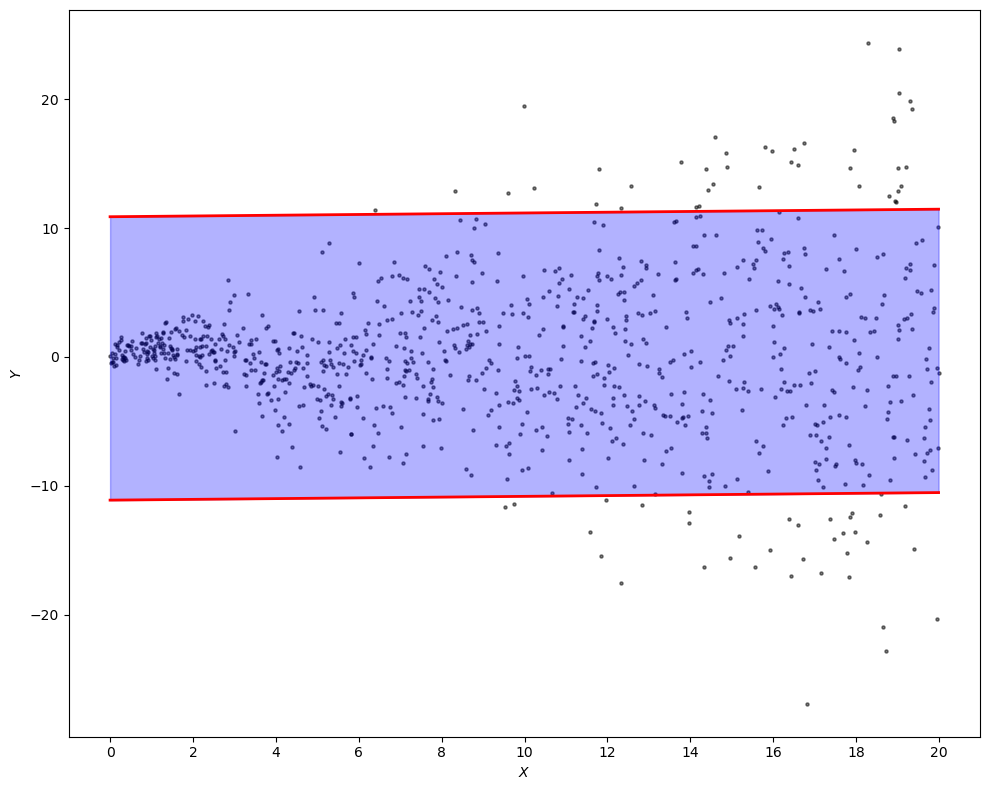

In [177]:
def plot_conformalized_data(X, y, y_pred, y_lower, y_upper):
    plt.figure(figsize=(10, 8))
    sort_indices = np.argsort(X.flatten())

    # TODO: plot the data
    plt.scatter(X, y, s=5, color="black", alpha=0.5)
    
    # TODO: plot the model predictions
    plt.plot(X[sort_indices], y_pred[sort_indices], color="red", linewidth=2, label="Prediction")

    # TODO: plot the prediction interval
    plt.fill_between(X[sort_indices].flatten(),
                     y_lower[sort_indices],
                     y_upper[sort_indices],
                     color="blue",
                     alpha=0.3,
                     label="Prediction Interval")
    
    plt.xlabel(r"$X$")
    plt.ylabel(r"$Y$")
    plt.xticks(np.arange(22, step=2))
    plt.tight_layout()
    plt.grid(False)
    plt.show()

plot_conformalized_data(X_test, y_test, y_pred_test, y_lower, y_upper)

In [178]:
# %load solutions/split/plot_conformalized_data.py

**Exercise.** Write a function called `evaluate_conformal_regression` that takes as input an array of ground-truth $y$-values along with an array of the lower limits and an array of the upper limits of the corresponding prediction intervals. It then computes and outputs the following two metrics:
1. `coverage`: The average number of intervals that contain the ground-truth values.
2. `avg_length`: The average length of the intervals.

**Questions.**
1. What value should we expect for the `coverage` metric?
2. What kind of values do we desire for the `avg_length` metric?


In [179]:
# TODO: implement the evaluate_conformal_regression function

def coverage(y_true, y_lower, y_upper):
    return np.mean((y_true >= y_lower) & (y_true <= y_upper))

def avg_length(y_lower, y_upper):
    return np.mean(y_upper - y_lower)

def evaluate_conformal_regression(y_test, y_lower, y_upper):
    coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
    avg_length = np.mean(y_upper - y_lower)
    return coverage, avg_length

In [180]:
# %load solutions/split/eval_conf_regressor.py

**Exercise.** Evaluate the conformalized model with the help of the `evaluate_conformal_regression` function and display the results.

In [181]:
# TODO: evaluate the conformal prediction regressor
cov, length = evaluate_conformal_regression(y_test, y_lower, y_upper)
print(f"Coverage: {cov:.3f}")
print(f"Average Length: {length:.3f}")

Coverage: 0.922
Average Length: 21.989


The evaluation seems to match the desired results. 

**Remark.** Note however (from the plot) how the interval length is constant, and does not match the heteroskedasticity of the data. Indeed, the theoretical guarantee in the CP theorem is true for the quantity $P(Y \in C_{\alpha}(X))$ averaged over $X$, but is not true in general for $P(Y\in C_{\alpha}(X)| X=x)$!

Next, we perform a similar conformalization procedure using the PUNCC library, this will allow us to compare results, but also to learn how the PUNCC library works so that we can use it in the future instead of coding the CP algorithms from scratch.

**Exercise (at home or in the end if you still have time).** Find the tutorial called *Introduction Tutorial* in the Readme page of the PUNCC github repository and dollow the steps presented in the *Conformal Regression* section in order to conformalize the linar regression model above using PUNCC:
1. Train the model using PUNCC rather than fitting it directly.
2. Compute the prediciton intervals.
3. Compute the evaluation metrics.
4. Use PUNCC's visualization tools to visualize the results.

In [182]:
# %load solutions/puncc/fit_reg.py

In [183]:
# %load solutions/puncc/calib_reg.py

In [184]:
# %load solutions/puncc/eval_reg.py

In [185]:
# %load solutions/puncc/viz_reg.py

## 3. Cross-Validation+ (CV+)
As seen during the lecture, practitionners are not always willing to sacrifice part of the training data for the calibration phase. Of course, this is not a problem for our toy case, where we can generate as many extra exmaples as we wish... but we will nevertheless implement
the *Cross-Validation+* algorithm, which allows to use the whole training dataset for training, instead of splitting it into a proper training set and a calibration set. This comes at the cost of having to train multiple models.

**Exercise.** Use the `KFold` class from `scikit-learn` to:
1. Train 10 different linear regression models according to the CV+ algorithm.
2. Compute the nonconformity scores on each of the folds.

**Exercise.** Try explaining on your own words what we are doing : 
1. How is data being used? 
2. Which data to train which model? 
3. What models are in use in the calculation of the nonconformity scores?

Store the models into a list of models called `models` and the scores in a numpy array called `scores`.

**Warning.** Read carefully the documentaion of the `Kfold` function, we will be using it again further down to compute the prediction sets and the point predictions on the test sets, and we need to make sure that the data is split in the exact same folds both times!

In [186]:
# TODO: train and compute scores according to the CV+ algorithm
from sklearn.model_selection import KFold

# TODO: Define the k-fold cross-validation scheme
kf = KFold(n_splits=5)

# Initialize empty lists to store models and scores
models = []
scores = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    #TODO: Split the data into training and validation sets
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]
    y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]
    
    #TODO: Initialize the linear model
    model = LinearRegression()

    #TODO: Train the linear model and store it in the models array
    model.fit(X_fold_train, y_fold_train)
    models.append(model)
    
    #TODO: Compute predictions on the validation set
    y_val_pred = model.predict(X_fold_val)

    #TODO: Compute nonconformity scores and append to lists
    fold_scores = abs_difference(y_fold_val, y_val_pred)
    scores.append(fold_scores)

# concatenate scores into a numpy array
scores = np.concatenate(scores)

In [ ]:
# %load solutions/cv/cv_train.py

**Exercise.** Use the CV+ algorithm to produce prediction intervals for nominal $\alpha=0.1$. Compute point predictions on the test set by averaging accross the 10 different models.

In [191]:
# Conformalize the model using the CV+ algorithm
alpha = 0.1

# Initialize lower and upper arrays
y_pred_test = []
y_lower = []
y_upper = []

for fold, (train_index, val_index) in enumerate(kf.split(scores)):

    y_pred = models[fold].predict(X_test)
    y_pred_test.append(y_pred)

    #TODO: Extract scores
    scores_fold = scores[train_index]

    #TODO: Update lower and upper arrays
    # Update lower and upper arrays
    y_lower.append(y_pred[:, np.newaxis] - scores_fold[np.newaxis, :])
    y_upper.append(y_pred[:, np.newaxis] + scores_fold[np.newaxis, :])

# Convert the lists y_lower and y_upper into numpy arrays
y_pred_test = np.stack(y_pred_test)
y_lower = np.concatenate(y_lower, axis=1)
y_upper = np.concatenate(y_upper, axis=1)

y_pred_test = np.mean(y_pred_test, axis=0)

# Compute prediction intervals using the numpy quantile function
alpha_lower_corrected = np.floor(alpha * (len(scores) + 1)) / len(scores)
alpha_upper_corrected = np.ceil((1 - alpha) * (len(scores) + 1)) / len(scores)
y_lower = np.quantile(y_lower, alpha_lower_corrected, axis=1, method="inverted_cdf")
y_upper = np.quantile(y_upper, alpha_upper_corrected, axis=1, method="inverted_cdf")

In [ ]:
# %load solutions/cv/cv_calib.py

**Exercise.** Evaluate and plot the results.

CV+ Coverage: 0.920
CV+ Average Length: 21.474


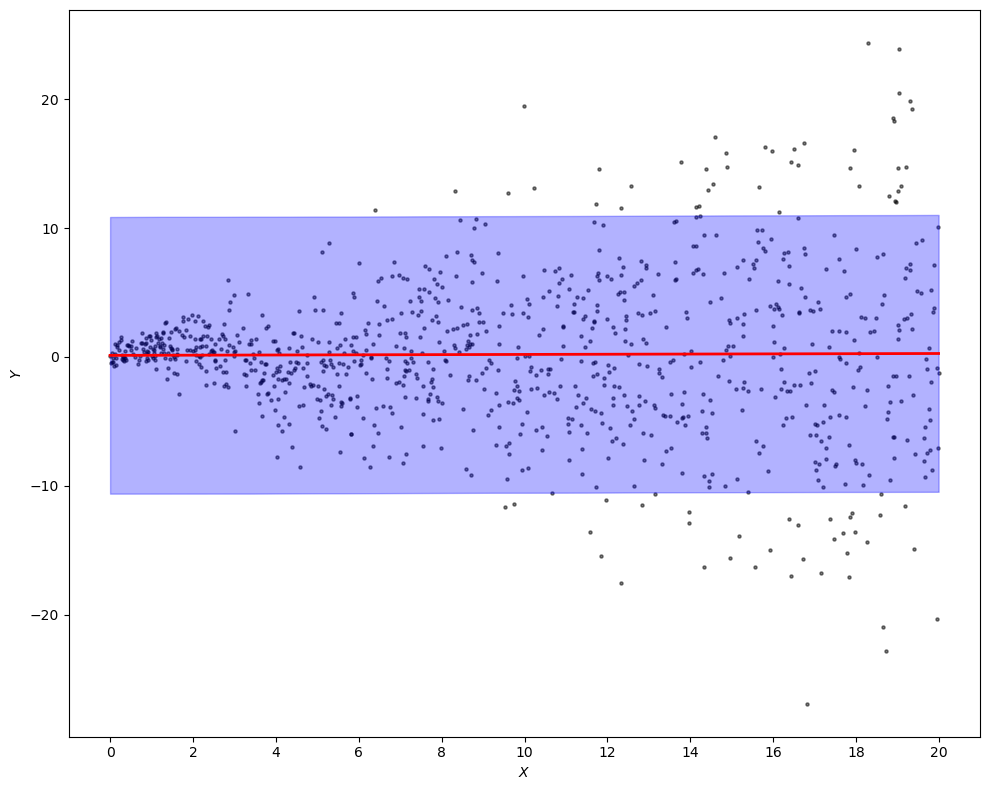

In [192]:
# TODO: Evaluate the results
cov_cv, length_cv = evaluate_conformal_regression(y_test, y_lower, y_upper)
print(f"CV+ Coverage: {cov_cv:.3f}")
print(f"CV+ Average Length: {length_cv:.3f}")

# TODO: plot the conformalized data
plot_conformalized_data(X_test, y_test, y_pred_test, y_lower, y_upper)

In [ ]:
# %load solutions/cv/cv_eval.py

**Exercise (at home or in the end if you still have time).** Perform the Cross-Validation using PUNCC and compare the result, there is no tutorial for this algorithm, but you can check the following section in the documentation to help yourself:

https://deel-ai.github.io/puncc/regression.html#deel.puncc.regression.CVPlus

In [ ]:
# %load solutions/puncc/cv_calib.py

In [ ]:
# %load solutions/puncc/cv_eval.py

Note that even if the guarantee provided by the CV+ method is
$$\mathbb{P}(Y_{n+1}\in \hat{C}_\alpha(X_{n+1})) \geq 1-2\alpha,$$
the achieved coverage rate is rather close to $1-\alpha$.

**Remark.** If you want to know more as to why this happens, you can check [this paper](https://arxiv.org/abs/1905.02928).

## 4. Conformal Quantile Regression
We now turn to the problem of the *constant* prediction intervals. As we can see in the plots above, the coverage rate of $1-\alpha$ is obtained by over-covering in the low-variance regions and under-covering in the high variance regions. We consider the *Conformalized Quantile Regression (CQR)* algorithm, the purpose of which is to generate prediction sets that are more adapted to the heteroskedasticity of the data. CQR extends traditional quantile regression by incorporating conformal prediction techniques, allowing us to construct predictive intervals with state-of-the-art performance and guaranteed coverage (under data exchangeability).

**Exercise.** Train lower and upper quantile models for a nominal eror rate $\alpha$ of 0.1, using the `GradientBoostingRegressor` model with 10 estimators from the `sklearn.ensemble` module.

**Careful!** The CQR algorithm is a kind of *split conformal* algorithm, so we need to use the *fit* data split to train the models, and hold out the *calibration* data split for the calibration phase.

In [205]:
# TODO: train the lower and upper quantile models

from sklearn.ensemble import GradientBoostingRegressor
lower_quantile_model = GradientBoostingRegressor(loss="quantile", alpha=alpha/2, n_estimators=10)
upper_quantile_model = GradientBoostingRegressor(loss="quantile", alpha=1 - alpha/2, n_estimators=10)

lower_quantile_model.fit(X_fit, y_fit)
upper_quantile_model.fit(X_fit, y_fit)

,loss,'quantile'
,learning_rate,0.1
,n_estimators,10
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [203]:
# %load solutions/cqr/train_quantiles.py

**Exercise.** Complete the `plot_quantile_model` function below and use it to plot the test examples along with the lower and upper quantile model predictions.

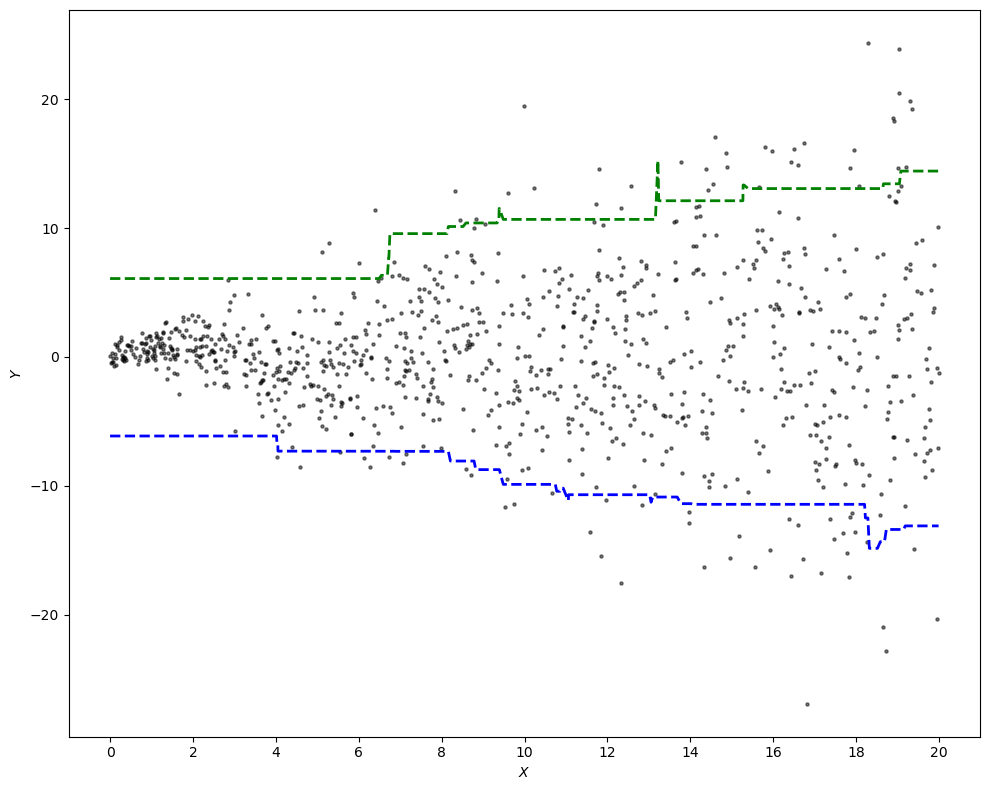

In [206]:
def plot_quantile_models(X, y, lower_quantile_model, upper_quantile_model):
    plt.figure(figsize=(10, 8))
    sort_indices = np.argsort(X.flatten())
    X_sorted = X[sort_indices]
    y_sorted = y[sort_indices]
    # TODO: plot the data
    plt.scatter(X, y, s=5, color="black", alpha=0.5)
    # TODO: plot the lower quantile predictions
    y_lower_pred = lower_quantile_model.predict(X_sorted)
    plt.plot(X_sorted, y_lower_pred, color="blue", linestyle="--", linewidth=2, label="Lower Quantile Prediction")

    # TODO: plot the upper quantile predictions
    y_upper_pred = upper_quantile_model.predict(X_sorted)
    plt.plot(X_sorted, y_upper_pred, color="green", linestyle="--", linewidth=2, label="Upper Quantile Prediction")

    plt.xlabel(r"$X$")
    plt.ylabel(r"$Y$")
    plt.xticks(np.arange(22, step=2))
    plt.tight_layout()
    plt.grid(False)
    plt.show()


plot_quantile_models(X_test, y_test, lower_quantile_model, upper_quantile_model)

In [207]:
# %load solutions/cqr/plot_quantiles.py

**Exercise.** Code the functions `cqr_score` and `cqr_set` so that we can use them along with the class `SplitConformal` above in order to implement the CQR algorithm. In order to keep a structure compatible with the `SplitConformal` class above, the `y_pred` input to the `cqr_score` and `cqr_set` functions is an array of length 2, where the first element contains the predictions of the lower quantile model and the second one the predictions of the upper quantile model.

**Careful!** There is a typo in the lecture notes!

In [ ]:
# TODO: implement the functions


In [213]:
# %load solutions/cqr/cqr_functions.py
def cqr_score(y_true, y_pred):
    return np.max(np.stack([y_pred[0] - y_true, y_true - y_pred[1]]), axis=0)

def cqr_set(y_pred, quantile):
    return y_pred[0] - quantile, y_pred[1] + quantile

**Exercise.** Conformalize the quantile regressors using the CQR algorithm and the calibration dataset.

In [230]:
y_pred_calib_lower = lower_quantile_model.predict(X_calib)
y_pred_calib_upper = upper_quantile_model.predict(X_calib)
y_pred_calib = np.stack([y_pred_calib_lower, y_pred_calib_upper])

alpha = 0.1

splitcr = SplitConformal(model=None, score_fn=cqr_score, predset_fn=cqr_set, alpha=alpha)

splitcr.compute_scores(y_calib=y_calib, y_pred=y_pred_calib)
splitcr.compute_quantile()

y_pred_test_lower = lower_quantile_model.predict(X_test)
y_pred_test_upper = upper_quantile_model.predict(X_test)
y_pred_test = np.stack([y_pred_test_lower, y_pred_test_upper])
y_lower, y_upper = splitcr.predict(y_pred=y_pred_test)

In [ ]:
# %load solutions/cqr/cqr_calib.py

**Exercise.** Evaluate and visualize the results of the CQR conformalized model.

Average prediction intervals width (sharpness): 18.642
Average coverage: 0.914


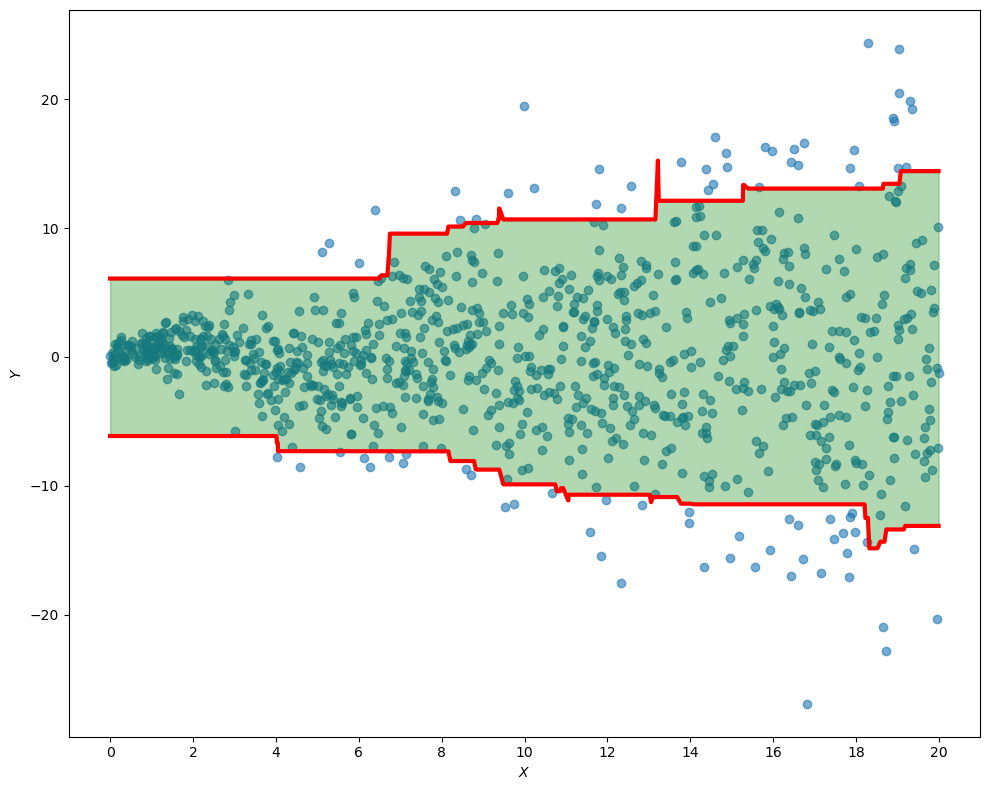

In [231]:
# TODO: evaluate the results and print the evaluation metrics
coverage, avg_length = evaluate_conformal_regression(y_test, y_lower, y_upper)
print(f"Average prediction intervals width (sharpness): {avg_length:.3f}")
print(f"Average coverage: {coverage:.3f}")

def plot_cqr_conformalized_data(X, y, y_pred_lower, y_pred_upper, y_lower, y_upper):
    plt.figure(figsize=(10, 8))
    sort_indices = np.argsort(X.flatten())
    X_sorted = X[sort_indices]
    y_pred_lower_sorted = y_pred_lower[sort_indices]
    y_pred_upper_sorted = y_pred_upper[sort_indices]
    y_lower_sorted = y_lower[sort_indices]
    y_upper_sorted = y_upper[sort_indices]

    plt.scatter(X, y, alpha=0.6)
    plt.plot(X_sorted, y_pred_lower_sorted, color="red", linewidth=3)
    plt.plot(X_sorted, y_pred_upper_sorted, color="red", linewidth=3)
    plt.fill_between(
        X_sorted.flatten(),
        y_lower_sorted,
        y_upper_sorted,
        alpha=0.3,
        color="green",
    )
    plt.xlabel(r"$X$")
    plt.ylabel(r"$Y$")
    plt.xticks(np.arange(22, step=2))
    plt.tight_layout()
    plt.grid(False)
    plt.show()

plot_cqr_conformalized_data(X_test, y_test, y_pred_test_lower, y_pred_test_upper, y_lower, y_upper)

In [228]:
# %load solutions/cqr/cqr_eval.py

**Questions.**
- What do you observe?
- Is this the expected behavior? Why?
- How does the average interval width compare with the previous methods?

**Exercise (at home or in the end if you still have time).** Implement the CQR algorithm in with PUNCC and compare the results with the ones obtained above.

In [ ]:
# %load solutions/puncc/cqr.py

# Part II: Conformal Classification

The objective of this section is to train a small neural network on the MNIST dataset and apply the Conformal Classification algorithms seen during the lecture.

 ## 1. Dataset
**Exercise.**
1. Import the MNIST dataset from keras.
2. Split the training set into a proper training set, which we call the `fit` dataset, and a calibration set. Use the first 50_000 training points for the fit dataset and the remaining ones for the calibration dataset.
3. Convert the labels to categorical, and save them into new arrays.

In [233]:
# TODO: Import and pre-process the data according to the instructions.

# TODO : Import the mnist dataset
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# TODO: Load the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing: reshaping and standardization
X_train = X_train.reshape((len(X_train), 28, 28))
X_train = X_train.astype('float32') / 255
X_test = X_test.reshape((len(X_test), 28 , 28))
X_test = X_test.astype('float32') / 255

X_fit, X_calib  = X_train[:50000], X_train[50000:]
y_fit, y_calib  = y_train[:50000], y_train[50000:]

y_fit_cat = to_categorical(y_fit, num_classes=10)
y_calib_cat = to_categorical(y_calib, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

2025-10-27 17:45:45.148613: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 17:45:50.790223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 17:46:29.115324: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# %load solutions/classif/data.py

## 2. Model

**Exercise.** Define a simple convolutional neural network having the following sequential architecture:
- A convolution with kernel size 3 and 16 channels.
- A ReLU activation.
- A max pooling layer with kernel size 2.
- A convolution with kernel size 3 and 32 channels.
- A reLU activation.
- A max pooling layer with kernel size 2.
- A Fully connected layer with 10 neurons.
- A softmax activation.

**Warning!** Use tensorflow, it is easier to use with PUNCC later.

In [235]:
from tensorflow import random
from tensorflow import keras
from tensorflow.keras import layers

random.set_seed(0)
keras.utils.set_random_seed(0)

# Classification model: convnet composed of two convolution/pooling layers
# and a dense output layer
nn_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Reshape((28, 28, 1)),
    layers.Conv2D(16, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), # non necessary but improves performance
    layers.Dense(10, activation='softmax')
])

In [ ]:
# %load solutions/classif/model.py

## 3. Training

**Exercise.** Train the model using the Adam optimizer, and the categorical cross-entropy loss. Plot the training and validation accuracy while training, with 10% of the fit data left out for the validation set.

Train the model for 2 epochs with a batch size of 256.

In [240]:
# training the model
nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0283 - val_accuracy: 0.9879 - val_loss: 0.0439
Epoch 2/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9930 - loss: 0.0236 - val_accuracy: 0.9888 - val_loss: 0.0432
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9940 - loss: 0.0201 - val_accuracy: 0.9892 - val_loss: 0.0412
Epoch 4/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9945 - loss: 0.0182 - val_accuracy: 0.9897 - val_loss: 0.0380


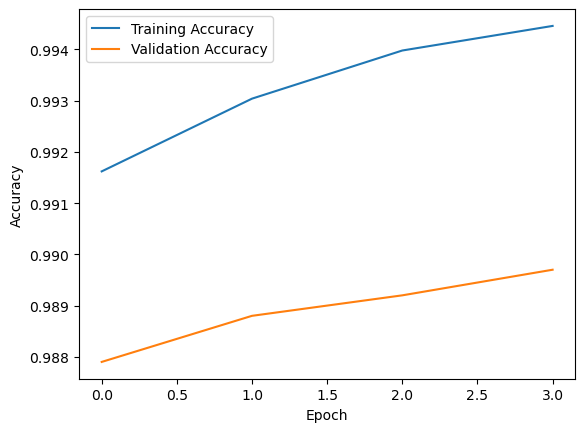

In [242]:
# Plot the training and validation accuracy while training, with 10% of the fit data left out for the validation set.
import matplotlib.pyplot as plt

history = nn_model.fit(X_fit, y_fit_cat, validation_data=(X_calib, y_calib_cat), epochs=4, batch_size=256)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# %load solutions/classif/train.py

## 4. Least Ambiguous Set-Valued Classifiers (LAC)
We now implement the LAC algorithm seen during the lecture.

**Exercise.** Define a `lac_score` and a `lac_set` function in order to be used with the `SplitConformal` class above.

In [249]:
# %load solutions/classif/lac_funcs.py
def lac_score(labels, probas):  # ✅ labels en premier maintenant
    scores = [1 - p[l] for p, l in zip(probas, labels)]
    return np.array(scores)

def lac_set(probas, quantile):
    return [np.where(p > 1 - quantile)[0] for p in probas]

**Exercise.** Conformalize the classification model.

In [245]:
y_pred_calib = nn_model.predict(X_calib)
y_pred_test = nn_model.predict(X_test)

2025-10-27 17:53:20.601625: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 20 bytes spill stores, 20 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step


In [250]:
# Prédictions
y_pred_calib = nn_model.predict(X_calib)
y_pred_test = nn_model.predict(X_test)

# Conformalize avec les labels ORIGINAUX
split_conformal_lac = SplitConformal(
    model=None, 
    score_fn=lac_score, 
    predset_fn=lac_set, 
    alpha=0.1
)
split_conformal_lac.compute_scores(y_calib=y_calib, y_pred=y_pred_calib)
split_conformal_lac.compute_quantile()

prediction_sets = split_conformal_lac.predict(y_pred=y_pred_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step


In [ ]:
# %load solutions/classif/lac_calib.py

**Exercise.** Evaluate the results by computing the average coverage and average size of the prediction sets on the test set.

In [252]:
def eval_conformal_classifier(y_true, y_predset):
    coverage = np.mean([y in predset for y, predset in zip(y_true, y_predset)])
    avg_size = np.mean([len(predset) for predset in y_predset])
    return coverage, avg_size

cov_lac, avg_size_lac = eval_conformal_classifier(y_test, prediction_sets)
print(f"LAC Coverage: {cov_lac:.3f}")
print(f"LAC Average Prediction Set Size: {avg_size_lac:.3f}")

LAC Coverage: 0.902
LAC Average Prediction Set Size: 0.903


In [ ]:
# %load solutions/classif/lac_eval.py

**Exercise.** Plot a random image along with the prediction set.

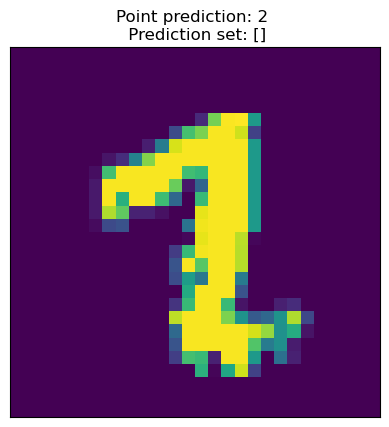

In [286]:
sample = np.random.randint(0, len(X_test))

plt.imshow(X_test[sample].reshape((28,28)))
_ = plt.title(f"Point prediction: {np.argmax(y_pred_test[sample])} \n Prediction set: {prediction_sets[sample]}")
_ = plt.xticks([])
_ = plt.yticks([])

**Questions.**
1. How come the average size of the prediction sets is smaller than 1?
2. Some of the prediction sets are empty, they contain no labels. Why? Do you think that this is an Ok behavior?

## 5. Regularized Adaptive Prediction Sets
**Exercise (at home or in the end if you still have time).** Follow the *Introduction Tutorial* in PUNCC, the section on *Conformal Classification* to implement the RAPS method as in the tutorial. Compare the results thus obtained with those obtained from the LAC method.

# To go further

1. Code the APS and RAPS algorithms from scratch without using PUNCC.
2. Check out the MAPIE library, which is a nice alternative to PUNCC.
3. Check out the algorithms for Conformal Anomaly Detection and Conformal Object Detection in PUNCC.